100%|██████████| 9.91M/9.91M [00:00<00:00, 59.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.49MB/s]


Epoch 1, Loss: 0.3588, Accuracy: 88.38%
Epoch 2, Loss: 0.1551, Accuracy: 95.02%
Epoch 3, Loss: 0.1208, Accuracy: 96.08%


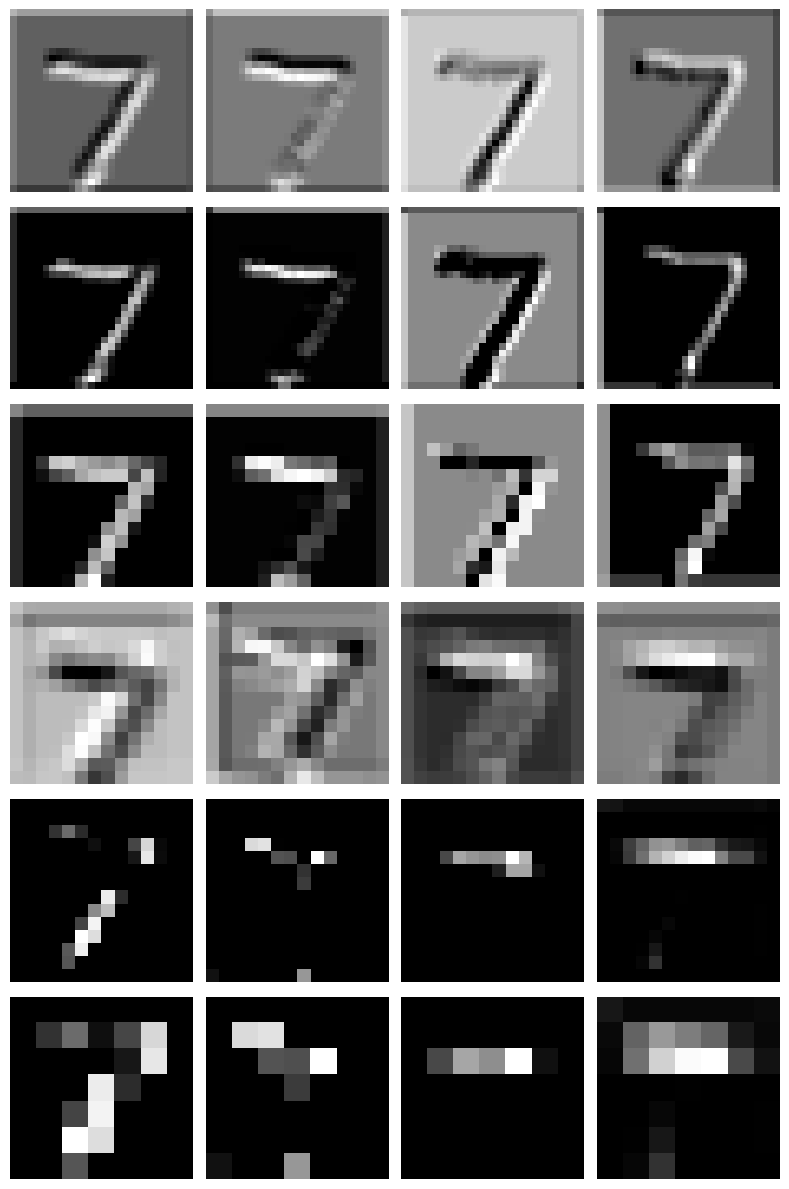

Final Test Accuracy: 96.50%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# --- 1. Dataset Preparation ---
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),   # Basic data augmentation
    transforms.ToTensor(),               # Convert PIL Image to PyTorch Tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize grayscale pixel values
])

# Load training data
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Load testing data
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# --- 2. Building the CNN ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: 1x28x28
        # Conv Layer 1: 3x3 filter, stride 1, padding 1, 16 filters
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 16x14x14

        # Conv Layer 2: 3x3 filter, stride 1, padding 1, 32 filters
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 32x7x7

        # Fully connected (FC) layer
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 7 * 7, 10) # 10 output classes for digits 0-9

    def forward(self, x):
        # Save intermediate feature maps for visualization
        self.out_conv1 = self.conv1(x)
        self.out_relu1 = self.relu1(self.out_conv1)
        self.out_pool1 = self.pool1(self.out_relu1)

        self.out_conv2 = self.conv2(self.out_pool1)
        self.out_relu2 = self.relu2(self.out_conv2)
        self.out_pool2 = self.pool2(self.out_relu2)

        # Flatten and pass to linear layer
        x = self.flatten(self.out_pool2)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# --- 3. Training the CNN ---
criterion = nn.CrossEntropyLoss() # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer

epochs = 3 # Kept small for quick execution
for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad() # Clear gradients from previous step

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate error
        loss.backward() # Backpropagation
        optimizer.step() # Update weights

        # Track accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}, Accuracy: {100 * correct / total:.2f}%")

# --- 4. Visualizing Feature Maps ---
def visualize_feature_maps(model, image):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        image = image.unsqueeze(0).to(device) # Add batch dimension (1, 1, 28, 28)
        _ = model(image) # Run inference to populate 'self.out_...' variables

        # Dictionary of saved feature maps
        maps = {
            'Conv1': model.out_conv1[0].cpu(),
            'ReLU1': model.out_relu1[0].cpu(),
            'Pool1': model.out_pool1[0].cpu(),
            'Conv2': model.out_conv2[0].cpu(),
            'ReLU2': model.out_relu2[0].cpu(),
            'Pool2': model.out_pool2[0].cpu()
        }

        # Plot the first 4 channels of each stage
        fig, axes = plt.subplots(6, 4, figsize=(8, 12))
        for row, (name, feature_map) in enumerate(maps.items()):
            for col in range(4):
                ax = axes[row, col]
                ax.imshow(feature_map[col], cmap='gray')
                if col == 0:
                    ax.set_ylabel(name, rotation=90, size='large')
                ax.axis('off')
        plt.tight_layout()
        plt.show()

# Get one test image
dataiter = iter(testloader)
images, labels = next(dataiter)
visualize_feature_maps(model, images[0]) # Visualize feature maps for the first image

# --- 5. Model Evaluation ---
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for data in testloader:
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Final Test Accuracy: {100 * correct / total:.2f}%")